# Counting: Combinatorics and the Art of Enumeration

## Learning Objectives

By the end of this notebook you will be able to:

1. Apply the **multiplication principle** to count outcomes of multi-step experiments.
2. Distinguish between **permutations** (order matters) and **combinations** (order doesn't).
3. Compute $P(n,r)$ and $\binom{n}{r}$ both **from scratch** and with `math.comb`.
4. Use counting to solve classical probability problems (cards, dice, birthdays).
5. Recognise when to apply the **multinomial coefficient**.

## Prerequisites

- [01_sample_spaces.ipynb](01_sample_spaces.ipynb) — sample spaces, events, classical probability $P(A) = |A|/|\Omega|$

In [ ]:
# Environment detection & setup
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    """Notebook-level configuration."""

    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr: str, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        plain = expr.replace(r"\binom", "C").replace("{", "(").replace("}", ")")
        return Text(plain, **kwargs)

    def save_gifs(self, clean: bool = True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. Why Counting Matters

In the previous notebook we saw that for equally likely outcomes:

$$P(A) = \frac{|A|}{|\Omega|}$$

This is clean and elegant — but only useful if we can actually **count** $|A|$ and $|\Omega|$. For a single die that's trivial ($|\Omega| = 6$). But what about:

- How many 5-card poker hands are there? ($|\Omega| = {?}$)
- How many of those are a flush? ($|A| = {?}$)
- In how many ways can 20 students be seated in a row?
- How many distinct anagrams does the word MISSISSIPPI have?

**Combinatorics** gives us the tools to answer these questions systematically.

---

## 2. The Multiplication Principle (Fundamental Counting Rule)

The most basic counting tool:

> **Theorem 2.1 (Multiplication principle).** If an experiment consists of $k$ stages, where stage $i$ has $n_i$ possible outcomes (regardless of what happened in earlier stages), then the total number of outcomes is
>
> $$|\Omega| = n_1 \times n_2 \times \cdots \times n_k$$

### Example: two dice

Rolling two dice is a two-stage experiment: die 1 has 6 outcomes, die 2 has 6 outcomes, so $|\Omega| = 6 \times 6 = 36$. We saw this in the previous notebook.

### Example: PIN codes

A 4-digit PIN where each digit is 0–9: $|\Omega| = 10 \times 10 \times 10 \times 10 = 10^4 = 10{,}000$.

### Example: licence plates

A plate has 3 letters (A–Z) followed by 4 digits (0–9): $|\Omega| = 26^3 \times 10^4 = 175{,}760{,}000$.

The animation below visualises the multiplication principle as a **tree diagram** — each branch at one level represents a choice, and the total number of paths through the tree equals the product of choices at each level.

In [2]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

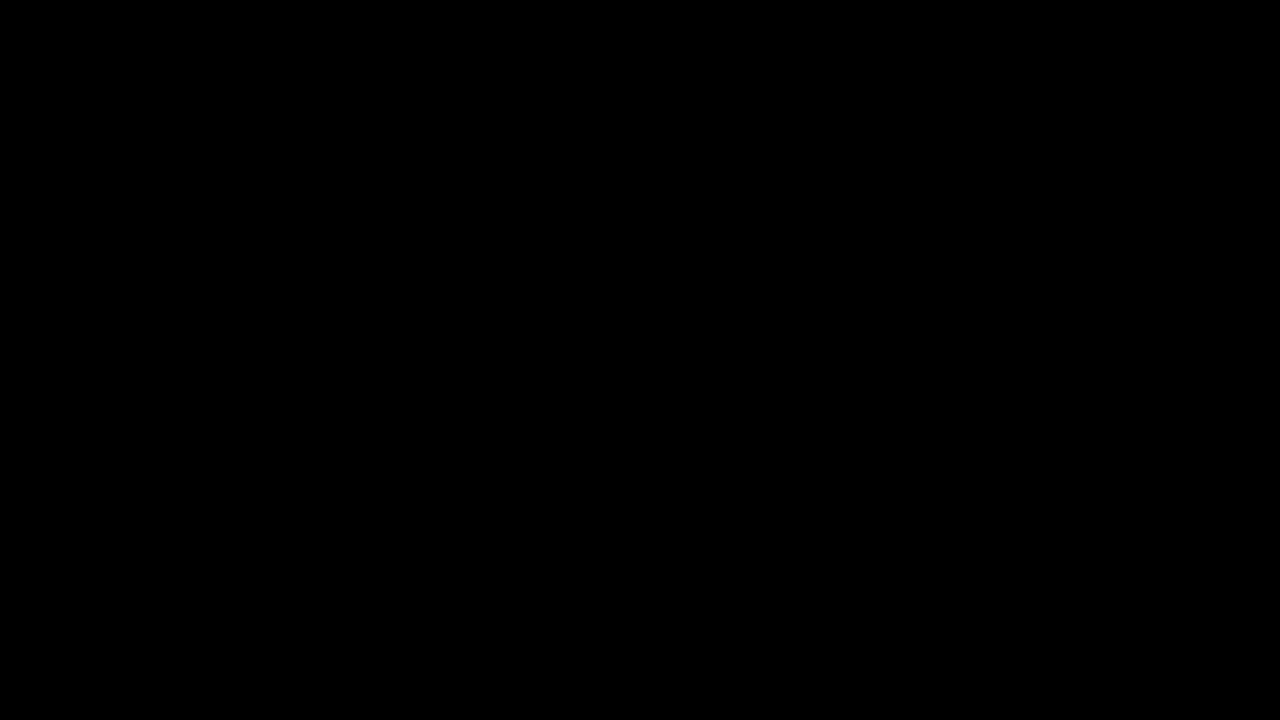

In [ ]:
%%manim -qm -v WARNING TreeDiagram


class TreeDiagram(Scene):
    """Animate a tree diagram for flipping a coin then rolling a die (faces 1-3)."""

    def construct(self):
        title = Text("Multiplication Principle: Coin + Die(1–3)", font_size=28).to_edge(
            UP
        )
        self.play(Write(title))

        # Root
        root = Dot(UP * 2, color=WHITE, radius=0.06)
        self.play(FadeIn(root))

        # Level 1: Coin flip (H, T)
        coin_labels = ["H", "T"]
        coin_colors = [C.SALMON, C.PERIWINKLE]
        coin_positions = [UP * 0.5 + LEFT * 2.5, UP * 0.5 + RIGHT * 2.5]
        coin_dots = []

        for i, (lbl, col, pos) in enumerate(
            zip(coin_labels, coin_colors, coin_positions)
        ):
            dot = Dot(pos, color=col, radius=0.06)
            line = Line(root.get_center(), pos, color=col, stroke_width=2)
            txt = Text(lbl, font_size=22, color=col).next_to(dot, UP, buff=0.1)
            self.play(Create(line), FadeIn(dot), Write(txt), run_time=0.5)
            coin_dots.append(dot)

        # Level 2: Die roll (1, 2, 3) for each coin outcome
        die_labels = ["1", "2", "3"]
        leaf_count = 0
        leaf_texts = []

        for ci, (cdot, clbl, ccol) in enumerate(
            zip(coin_dots, coin_labels, coin_colors)
        ):
            offsets = [-1.2, 0, 1.2]
            base_x = cdot.get_center()[0]
            for di, (dlbl, dx) in enumerate(zip(die_labels, offsets)):
                pos = DOWN * 1.5 + RIGHT * (base_x + dx)
                dot = Dot(pos, color=C.EMERALD, radius=0.05)
                line = Line(cdot.get_center(), pos, color=GREY, stroke_width=1.5)
                outcome = f"{clbl}{dlbl}"
                txt = Text(outcome, font_size=18, color=C.GOLD).next_to(
                    dot, DOWN, buff=0.1
                )
                self.play(Create(line), FadeIn(dot), Write(txt), run_time=0.25)
                leaf_count += 1
                leaf_texts.append(txt)

        # Show total count
        total = math_text(
            r"|\Omega| = 2 \times 3 = 6", font_size=28, color=C.GOLD
        ).to_edge(DOWN)
        self.play(Write(total))
        self.wait(1.5)

Each path from root to leaf is one outcome. We have 2 choices (H or T) at the first level and 3 choices (1, 2, 3) at the second, giving $2 \times 3 = 6$ total outcomes — exactly the number of leaf nodes.

---

## 3. Permutations — When Order Matters

A **permutation** is an ordered arrangement. How many ways can we arrange $r$ items chosen from $n$ distinct items?

By the multiplication principle:
- First position: $n$ choices
- Second position: $n - 1$ choices (one item used)
- ...
- $r$-th position: $n - r + 1$ choices

> **Definition 2.2 (Permutations).** The number of ordered arrangements of $r$ items from $n$ is
>
> $$P(n, r) = n \cdot (n-1) \cdot (n-2) \cdots (n-r+1) = \frac{n!}{(n-r)!}$$

**Special case:** Arranging *all* $n$ items gives $P(n, n) = n!$ ("$n$ factorial").

### Examples

- **Podium finishes:** In a race with 10 runners, the number of possible gold-silver-bronze outcomes is $P(10, 3) = 10 \times 9 \times 8 = 720$.
- **Seating:** 5 people in 5 chairs: $P(5, 5) = 5! = 120$.

### From-scratch implementation

Let's implement this ourselves before using `math.perm`:

In [ ]:
# Stage 2: FROM SCRATCH
def factorial(n):
    """Compute n! iteratively."""
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


def perm(n, r):
    """Number of permutations: P(n, r) = n! / (n-r)!"""
    result = 1
    for i in range(n, n - r, -1):  # n, n-1, ..., n-r+1
        result *= i
    return result


print(f"5! = {factorial(5)}")
print(f"P(10, 3) = {perm(10, 3)}")
print(f"P(5, 5) = {perm(5, 5)} = 5! = {factorial(5)}")

5! = 120
P(10, 3) = 720
P(5, 5) = 120 = 5! = 120


In [5]:
# Stage 3: PROFESSIONAL — math.perm (Python 3.8+) and math.factorial
from math import perm as math_perm, factorial as math_factorial

print(f"math.factorial(5) = {math_factorial(5)}")
print(f"math.perm(10, 3)  = {math_perm(10, 3)}")

# Verify they match
assert perm(10, 3) == math_perm(10, 3)
assert factorial(20) == math_factorial(20)
print("\n✓ Our scratch implementations match the standard library.")

math.factorial(5) = 120
math.perm(10, 3)  = 720

✓ Our scratch implementations match the standard library.


---

## 4. Combinations — When Order Doesn't Matter

Often we don't care about the order of selection — only *which* items are chosen. A poker hand $\{A\heartsuit, K\spadesuit, 7\clubsuit, 3\diamondsuit, 9\heartsuit\}$ is the same hand regardless of the order it was dealt.

Since every set of $r$ items can be arranged in $r!$ ways, the number of **unordered** selections is:

> **Definition 2.3 (Combinations / binomial coefficient).** The number of ways to choose $r$ items from $n$ without regard to order is
>
> $$\binom{n}{r} = \frac{P(n,r)}{r!} = \frac{n!}{r!\,(n-r)!}$$
>
> Read "$n$ choose $r$".

### Key properties

- **Symmetry:** $\binom{n}{r} = \binom{n}{n-r}$ — choosing $r$ items to include is the same as choosing $n - r$ items to exclude.
- **Boundary cases:** $\binom{n}{0} = \binom{n}{n} = 1$.
- **Pascal's rule:** $\binom{n}{r} = \binom{n-1}{r-1} + \binom{n-1}{r}$ — the basis of Pascal's triangle.

### Examples

- **Poker hands:** $\binom{52}{5} = 2{,}598{,}960$ possible 5-card hands.
- **Lottery:** Choosing 6 numbers from 49: $\binom{49}{6} = 13{,}983{,}816$.
- **Committee:** Choosing 3 people from a group of 8: $\binom{8}{3} = 56$.

In [ ]:
# Stage 2: FROM SCRATCH
def choose(n, r):
    """Binomial coefficient C(n, r) = n! / (r! * (n-r)!).

    Uses the incremental product to avoid computing huge factorials:
    C(n,r) = (n * (n-1) * ... * (n-r+1)) / (1 * 2 * ... * r)
    """
    if r > n:
        return 0
    if r > n - r:  # use symmetry to minimise multiplications
        r = n - r
    result = 1
    for i in range(r):
        result = result * (n - i) // (i + 1)
    return result


print(f"C(52, 5) = {choose(52, 5):,}")
print(f"C(49, 6) = {choose(49, 6):,}")
print(f"C(8, 3)  = {choose(8, 3)}")
print(f"C(10, 0) = {choose(10, 0)}")
print(f"C(10, 10)= {choose(10, 10)}")

# Verify symmetry
print(f"\nSymmetry: C(10, 3) = {choose(10, 3)}, C(10, 7) = {choose(10, 7)}")

C(52, 5) = 2,598,960
C(49, 6) = 13,983,816
C(8, 3)  = 56
C(10, 0) = 1
C(10, 10)= 1

Symmetry: C(10, 3) = 120, C(10, 7) = 120


In [7]:
# Stage 3: PROFESSIONAL — math.comb (Python 3.8+)
from math import comb

print(f"math.comb(52, 5) = {comb(52, 5):,}")
print(f"math.comb(49, 6) = {comb(49, 6):,}")

# Verify
assert choose(52, 5) == comb(52, 5)
assert choose(100, 50) == comb(100, 50)
print("\n✓ Our choose() matches math.comb().")

math.comb(52, 5) = 2,598,960
math.comb(49, 6) = 13,983,816

✓ Our choose() matches math.comb().


### Permutations vs. combinations: when does order matter?

The key question is always: **does rearranging the selected items produce a different outcome?**

| Situation                              | Order matters?         | Formula                  |
|----------------------------------------|------------------------|--------------------------|
| Podium finishes (gold, silver, bronze) | Yes — different medals | $P(n, r)$                |
| PIN code (1234 ≠ 4321)                 | Yes — different PINs   | $n^r$ (with replacement) |
| Poker hand                             | No — same cards        | $\binom{n}{r}$           |
| Committee selection                    | No — same group        | $\binom{n}{r}$           |
| Batting order for a baseball team      | Yes — different lineup | $P(n, r)$                |

---

## 5. Pascal's Triangle

Pascal's triangle arranges the binomial coefficients in a triangular grid where each entry is the sum of the two entries above it:

$$\binom{n}{r} = \binom{n-1}{r-1} + \binom{n-1}{r}$$

This is not just a pretty pattern — it gives a **recursive** way to compute $\binom{n}{r}$ and appears throughout probability (the binomial distribution, random walks, etc.).

The animation below builds Pascal's triangle row by row, showing how each number is the sum of the two above.

Manim Community v0.18.1

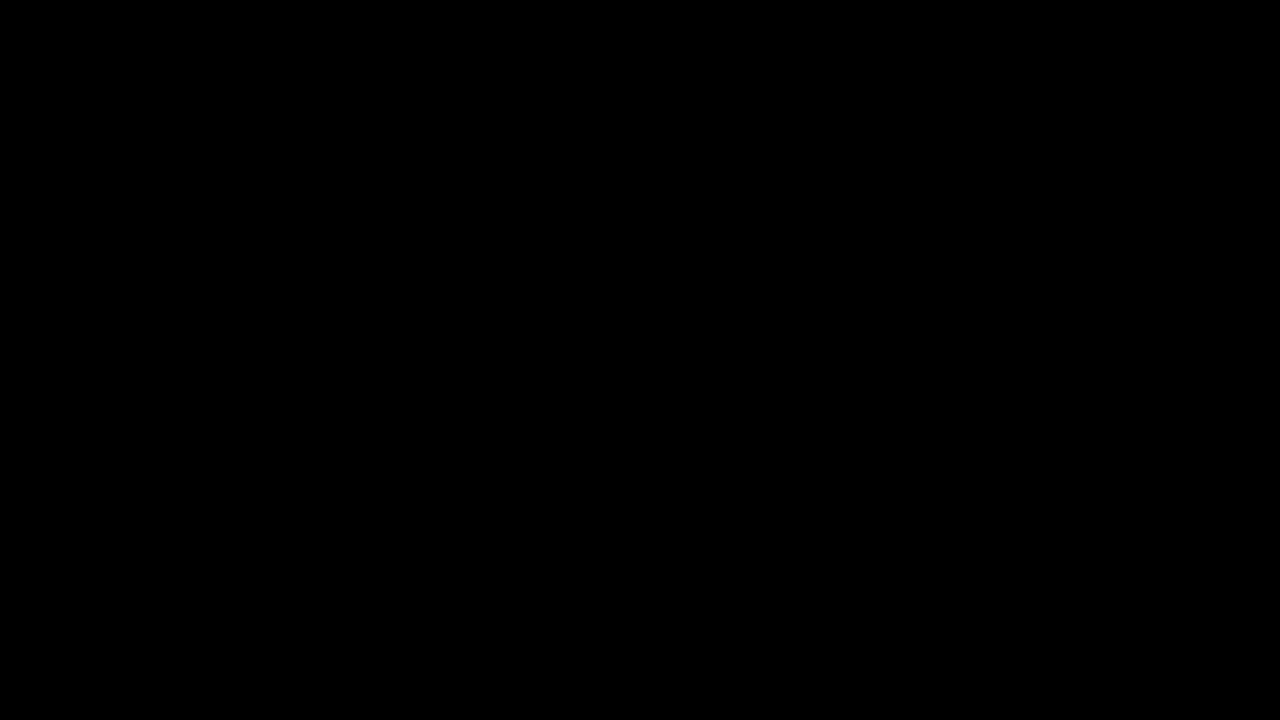

In [ ]:
%%manim -qm -v WARNING PascalTriangle


class PascalTriangle(Scene):
    """Build Pascal's triangle row by row."""

    def construct(self):
        title = Text("Pascal's Triangle", font_size=32).to_edge(UP)
        self.play(Write(title))

        n_rows = 7
        entries = []  # list of lists of Mobjects
        y_start = 2.0
        y_step = -0.75
        x_step = 0.7

        for n in range(n_rows):
            row = []
            y = y_start + n * y_step
            x_offset = -n * x_step / 2
            for r in range(n + 1):
                val = choose(n, r)
                x = x_offset + r * x_step
                color = C.PERIWINKLE if (r == 0 or r == n) else C.SALMON
                txt = Text(str(val), font_size=22, color=color).move_to([x, y, 0])
                row.append(txt)
            entries.append(row)

            if n <= 1:
                self.play(*[Write(t) for t in row], run_time=0.5)
            else:
                # Highlight the addition: show arrows from parents
                anims = []
                for r, txt in enumerate(row):
                    anims.append(FadeIn(txt, shift=DOWN * 0.2))
                self.play(*anims, run_time=0.4)

        # Label the rule
        rule = math_text(
            r"\binom{n}{r} = \binom{n-1}{r-1} + \binom{n-1}{r}",
            font_size=26,
            color=C.GOLD,
        ).to_edge(DOWN)
        self.play(Write(rule))
        self.wait(1.5)

Row $n$ of the triangle contains $\binom{n}{0}, \binom{n}{1}, \dots, \binom{n}{n}$. Notice the symmetry ($\binom{n}{r} = \binom{n}{n-r}$) and that the edges are always 1.

---

## 6. Applying Counting to Probability

Now we have the tools to solve real probability problems. The recipe is always:

1. Define the sample space $\Omega$ and compute $|\Omega|$ using counting.
2. Define the event $A$ and compute $|A|$ using counting.
3. Apply $P(A) = |A|/|\Omega|$.

### Example 1: Poker — probability of a flush

A **flush** is 5 cards all of the same suit.

- $|\Omega| = \binom{52}{5}$ (all possible 5-card hands).
- For a flush: choose 1 suit out of 4, then choose 5 cards from the 13 in that suit: $|A| = 4 \times \binom{13}{5}$.

$$P(\text{flush}) = \frac{4 \times \binom{13}{5}}{\binom{52}{5}}$$

In [ ]:
# Analytical
flush_count = 4 * choose(13, 5)
total_hands = choose(52, 5)
p_flush = flush_count / total_hands

print(f"|Ω| = C(52,5) = {total_hands:,}")
print(f"|A| = 4 × C(13,5) = {flush_count:,}")
print(
    f"P(flush) = {flush_count}/{total_hands} = {p_flush:.6f} ≈ 1 in {1 / p_flush:.0f}"
)

# Simulation to verify
rng = np.random.default_rng(42)
n_sims = 500_000
deck = np.arange(52)  # cards 0-51; suit = card // 13
flush_sim = 0

for _ in range(n_sims):
    hand = rng.choice(deck, size=5, replace=False)
    suits = hand // 13
    if np.all(suits == suits[0]):
        flush_sim += 1

print(f"\nSimulated P(flush) = {flush_sim / n_sims:.6f}  (n = {n_sims:,})")

|Ω| = C(52,5) = 2,598,960
|A| = 4 × C(13,5) = 5,148
P(flush) = 5148/2598960 = 0.001981 ≈ 1 in 505

Simulated P(flush) = 0.001956  (n = 500,000)


### Example 2: The Birthday Problem

One of the most famous results in combinatorial probability:

> In a group of $n$ people, what is the probability that **at least two** share a birthday?

Assume 365 equally likely birthdays (ignore leap years). It's easier to compute the **complement** — the probability that *all* birthdays are distinct:

$$P(\text{all different}) = \frac{365}{365} \cdot \frac{364}{365} \cdot \frac{363}{365} \cdots \frac{365 - n + 1}{365} = \frac{P(365, n)}{365^n}$$

So:

$$P(\text{at least one match}) = 1 - \frac{P(365, n)}{365^n}$$

The result is famously counter-intuitive: with just **23 people**, the probability exceeds 50%.

In [10]:
# Birthday problem: analytical + simulation
def birthday_prob(n):
    """Probability that at least 2 of n people share a birthday."""
    p_all_different = 1.0
    for i in range(n):
        p_all_different *= (365 - i) / 365
    return 1 - p_all_different


# Print key values
for n in [10, 20, 23, 30, 50, 70]:
    print(f"n = {n:2d}: P(match) = {birthday_prob(n):.4f}")

n = 10: P(match) = 0.1169
n = 20: P(match) = 0.4114
n = 23: P(match) = 0.5073
n = 30: P(match) = 0.7063
n = 50: P(match) = 0.9704
n = 70: P(match) = 0.9992


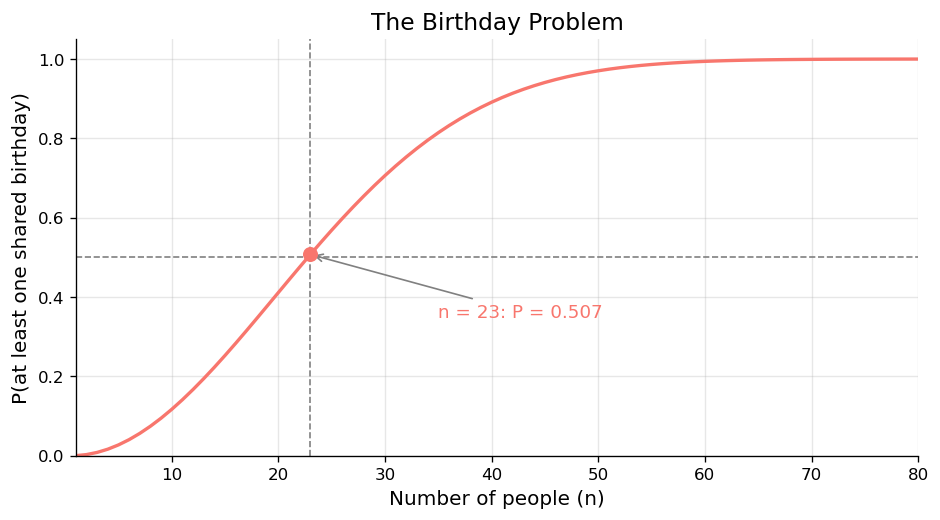

In [ ]:
# Plot the birthday curve
ns = np.arange(1, 81)
probs = [birthday_prob(n) for n in ns]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ns, probs, linewidth=2)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.axvline(23, color="grey", linestyle="--", linewidth=1)
ax.plot(23, birthday_prob(23), "o", color="#F8766D", markersize=8, zorder=5)
ax.annotate(
    f"n = 23: P = {birthday_prob(23):.3f}",
    xy=(23, birthday_prob(23)),
    xytext=(35, 0.35),
    arrowprops=dict(arrowstyle="->", color="grey"),
    fontsize=11,
    color="#F8766D",
)
ax.set_xlabel("Number of people (n)")
ax.set_ylabel("P(at least one shared birthday)")
ax.set_title("The Birthday Problem")
ax.set_xlim(1, 80)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Why is the number so low? Because we're not asking about a *specific* birthday — we're asking about *any* match among $\binom{n}{2}$ pairs. With 23 people there are $\binom{23}{2} = 253$ pairs, each with a $1/365$ chance of matching. The probabilities compound quickly.

---

## 7. The Multinomial Coefficient

Sometimes we need to divide $n$ items into **more than two** groups. The generalisation of $\binom{n}{r}$:

> **Definition 2.4 (Multinomial coefficient).** The number of ways to divide $n$ items into groups of sizes $k_1, k_2, \dots, k_m$ (where $k_1 + k_2 + \cdots + k_m = n$) is
>
> $$\binom{n}{k_1, k_2, \dots, k_m} = \frac{n!}{k_1! \, k_2! \cdots k_m!}$$

### Example: anagrams of MISSISSIPPI

MISSISSIPPI has 11 letters: M(1), I(4), S(4), P(2).

$$\text{Anagrams} = \frac{11!}{1! \cdot 4! \cdot 4! \cdot 2!} = 34{,}650$$

In [12]:
# From scratch
def multinomial(n, groups):
    """Multinomial coefficient: n! / (k1! * k2! * ... * km!)."""
    result = factorial(n)
    for k in groups:
        result //= factorial(k)
    return result


# MISSISSIPPI: M=1, I=4, S=4, P=2
anagrams = multinomial(11, [1, 4, 4, 2])
print(f"Anagrams of MISSISSIPPI: {anagrams:,}")

# Verify: this is also C(11,1) * C(10,4) * C(6,4) * C(2,2)
check = choose(11, 1) * choose(10, 4) * choose(6, 4) * choose(2, 2)
print(f"Sequential choice check: {check:,}")
assert anagrams == check

Anagrams of MISSISSIPPI: 34,650
Sequential choice check: 34,650


---

## 8. Summary: Counting Cheat Sheet

| Scenario                                       | Formula                              | Python              |
|------------------------------------------------|--------------------------------------|---------------------|
| Ordered, with replacement ($r$ picks from $n$) | $n^r$                                | `n**r`              |
| Ordered, without replacement (permutations)    | $P(n,r) = \frac{n!}{(n-r)!}$         | `math.perm(n, r)`   |
| Unordered, without replacement (combinations)  | $\binom{n}{r} = \frac{n!}{r!(n-r)!}$ | `math.comb(n, r)`   |
| Dividing into groups (multinomial)             | $\frac{n!}{k_1! k_2! \cdots k_m!}$   | Custom (see above)  |
| All arrangements of $n$ items                  | $n!$                                 | `math.factorial(n)` |

---

## Exercises

**Exercise 2.1 (Multiplication principle).** A restaurant offers 3 appetisers, 5 mains, and 4 desserts. How many different 3-course meals are possible?

**Exercise 2.2 (Permutations).** How many distinct 3-letter "words" (not necessarily real words) can be formed from the 26 English letters, if (a) repetition is allowed, (b) repetition is not allowed?

**Exercise 2.3 (Combinations).** A committee of 4 is to be chosen from 6 men and 5 women. How many committees are possible if (a) there are no restrictions, (b) the committee must have exactly 2 men and 2 women?

**Exercise 2.4 (Poker).** Compute the probability of being dealt (a) four of a kind, (b) a full house (three of one rank + two of another). Verify each with a simulation.

**Exercise 2.5 (Birthday).** Modify the birthday problem: in a room of 30 people, what is the probability that at least **three** people share a birthday? (*Hint:* simulation is easier than the exact calculation.)

**Exercise 2.6 (Multinomial).** How many distinct arrangements of the letters in STATISTICS are there?

**Exercise 2.7 (Challenge — Pascal's rule).** Prove algebraically that $\binom{n}{r} = \binom{n-1}{r-1} + \binom{n-1}{r}$ using the factorial definition.

---

## Key Takeaways

1. The **multiplication principle** is the foundation: if a multi-step process has $n_1, n_2, \dots, n_k$ choices at each step, the total is $n_1 \times n_2 \times \cdots \times n_k$.
2. **Permutations** ($P(n,r) = n!/(n-r)!$) count ordered selections; **combinations** ($\binom{n}{r}$) count unordered ones.
3. The **binomial coefficient** $\binom{n}{r}$ is the central object — it appears in Pascal's triangle, the binomial theorem, and the binomial distribution (Module 02).
4. For probability: define $\Omega$, count $|\Omega|$ and $|A|$, then $P(A) = |A|/|\Omega|$. Counting gives us the numerator and denominator.
5. The **birthday problem** shows that our intuition about probabilities is often wrong — always compute.

**Next:** [03_conditional_probability.ipynb](03_conditional_probability.ipynb) — What happens when we have partial information? Conditional probability and Bayes' theorem.

In [13]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/PascalTriangle@2026-03-19@13-44-25.gif
  ✓ media/gifs/TreeDiagram@2026-03-19@13-44-07.gif
  ✓ media/gifs/PascalTriangle_ManimCE_v0.18.1.gif
  ✓ media/gifs/TreeDiagram_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
